## Acrobot

The [Acrobot](https://gymnasium.farama.org/environments/classic_control/acrobot/) is a classic problem in control theory. The environment consists of two links connected linearly to form a chain, with one end of the chain fixed. The joint between the two links is actuated. The goal is to apply torques on the actuated joint to swing the free end of the linear chain above a given height while starting from the initial state of hanging downwards.

- The action space is discrete, deterministic, and represents the torque applied on the actuated joint between the two links: (0) apply -1 torque, (1) apply 0 torque to the actuated joint, (2) apply 1 torque to the actuated joint
- The observation space is a 6-dimensional space with the sine and cosine of the two joint angles and their angular velocities.

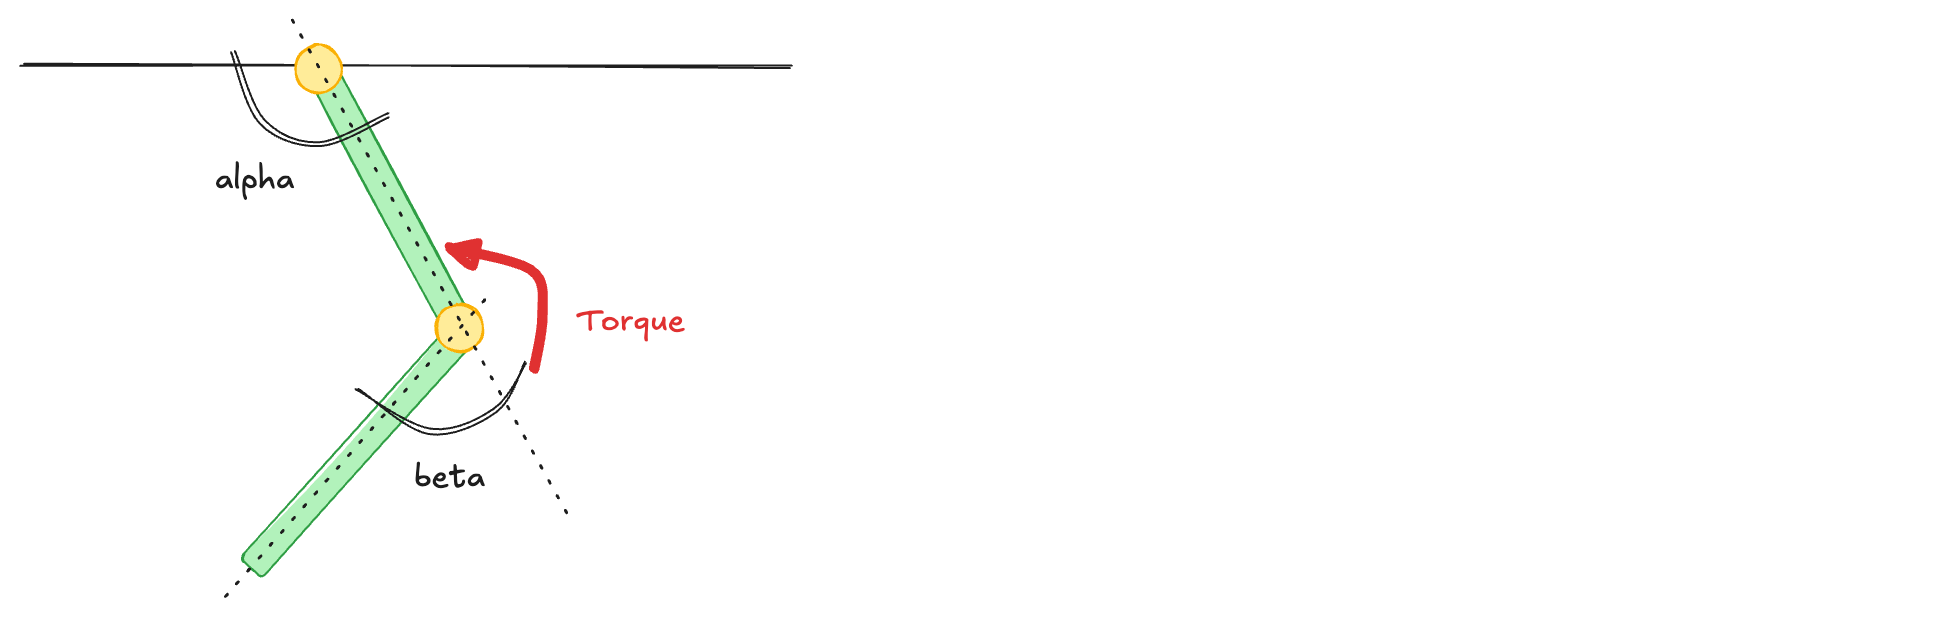

The goal is to have the free-end reach a designated target height in as few steps as possible, and as such all steps that do not reach the goal incur a reward of -1. Achieving the target height results in termination with a reward of 0. The reward threshold is -100.

1 - import the environment from Gymnasium and show it with a random policy

In [18]:
# YOUR CODE HERE

# You can get the environment from Gymnasium 'Acrobot-v1’; 
# In order to visually plot the environment you can import it 
# using render_mode="rgb_array". Get also th state size
# and action_size.

import gymnasium

env = gymnasium.make('Acrobot-v1', render_mode="rgb_array");

state_size = env.observation_space.shape;
action_size = env.action_space.n;

print('State Space: ', state_size);
print('Action Space: ', action_size);

State Space:  (6,)
Action Space:  3


2 - Show the policy in action by rendering the environment several times after different decisions from a random policy:

In [19]:
# YOUR CODE HERE

# You can use the same function already used for the cartpole environment to 
# implement a random aget and to show the policy.

import numpy as np

def random_pi(state):
    # selects an action uniformly at random
    # from the environment's action space.
    return env.action_space.sample()

In [20]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

def show_policy(pi, n_episodes=1, max_steps=500):

    # start the episodes    
    for episode in range(n_episodes):

        # reset the environment
        state, _ = env.reset();
        done = False;

        # initialize the step counter
        step = 0;

        # run the episode until done or max_steps
        while not done and step < max_steps:

            # make a step
            action = pi(state);
            state, _, terminated, truncated, _ = env.step(action);
            done = terminated or truncated;
            
            # render the environment
            clear_output(wait=True)
            plt.imshow(env.render())
            plt.axis("off")
            plt.title(f"Episode {episode+1}, Step {step}")
            plt.show()
            plt.close()

            # increment the step counter
            step += 1;   

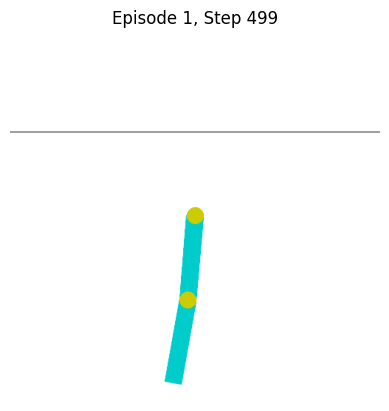

In [21]:
show_policy(random_pi, n_episodes=1, max_steps=500);

3 - Create the evaluation function for a policy

In [22]:
# YOUR CODE HERE

# It is the code to run the policy several times and show the
# average reward.

def evaluate(pi, episodes=1):

    # collect total rewards per episode
    rewards = [];

    # loop over episodes
    for episode in range(episodes):

        # reset the environment
        state, _ = env.reset();
        done = False;
        total_reward = 0.0;

        # run an episode
        while not done:
            action = pi(state);
            state, reward, terminal, truncated, _ = env.step(action)
            total_reward += reward;
            done = terminal or truncated;

        # store the total reward    
        rewards.append(total_reward);
    
    # return the average reward over the episodes
    return float(np.mean(rewards))


4 - Create a neural network as a function approximator for the Q-function

In [23]:
# YOUR CODE HERE

# Add the code for a neural network using the PyTorch library and
# the code of an optimizer as in the cartpole example

import torch

# Define hyperparameters for the neural network
first_hidden_layer= 512;
second_hidden_layer= 128;

def create_network():

      # Define a deep neural network using Sequential:
      # Each layer feeds directly into the next one.
      dnn = torch.nn.Sequential( 
            # First fully connected layer maps state inputs to 512 hidden units
            torch.nn.Linear(state_size[0], first_hidden_layer),
            
            # ReLU activation introduces nonlinearity
            torch.nn.ReLU(),
            
            # Second fully connected layer (hidden layer with 128 units)
            torch.nn.Linear(first_hidden_layer, second_hidden_layer),
            
            # Another ReLU activation
            torch.nn.ReLU(),
            
            # Output layer: one unit per possible action
            # Produces Q-values
            torch.nn.Linear(second_hidden_layer, action_size)
      )
    
      # Return the constructed model
      return dnn;

In [24]:
q = create_network();

learning_rate = 0.0001;
optimizer = torch.optim.RMSprop(q.parameters(), lr=learning_rate);

5 - Create a policy that is greedy with respect to the Q-function

In [25]:
# YOUR CODE HERE

# Write a function that, given a state, returns the action
# that maximizes the Q-function.

def nfq_pi(state):

    # convert state to a torch tensor
    state = torch.as_tensor(state, dtype=torch.float32)

    # compute Q-values from the network
    q_values = q(state).detach().numpy().squeeze()

    # select greedy action
    action = int(np.argmax(q_values))

    return action

6 - Add the code for the experience buffer

In [26]:
# YOUR CODE HERE

# Add the code for the experience buffer as in the cartpole example

# define the batch size
batch_size = 1024;

# define the structured dtype for an experience tuple
experience_type = np.dtype([
    ('state',      np.float32, state_size),   # current state
    ('action',     np.int8),                  # action taken
    ('reward',     np.float32),               # reward received
    ('next_state', np.float32, state_size),   # next state
    ('failure',    np.int8)                   # terminal flag (1 if done)
])

7 - Add the code of the exploration strategy based on epsilon-greedy method:

In [27]:
# YOUR CODE HERE

# Add the code for an exploration strategy based on the epsilon-greedy algorithm

import random;

# Exploration vs exploitation parameter
epsilon = 0.5

def epsilon_greedy(state):

    # Exploration
    if random.random() < epsilon:
        action = random_pi(state)

    # Exploitation
    else:
        action = nfq_pi(state)
        
    return action

8 - Add the code to train the neural network using the collected experiences:

In [28]:
# YOUR CODE HERE

# Re-use the optimize method as in the cartpole example

# define the discount factor
gamma = 0.99;

# define the number of optimization epochs
epochs = 40;

def optimize(batch):

    # convert experience fields to tensors
    states      = torch.from_numpy(batch['state'].copy()).float()        
    actions     = torch.from_numpy(batch['action'].copy()).long()        
    rewards     = torch.from_numpy(batch['reward'].copy()).float()       
    next_states = torch.from_numpy(batch['next_state'].copy()).float()   
    failures    = torch.from_numpy(batch['failure'].copy()).float()      

    # perform multiple epochs of optimization
    for epoch in range(epochs):

        # compute target: r + γ * max_a Q(next_state, a') * (1 - done)
        # remember to detach, we need to treat these values as constants! 
        with torch.no_grad():
            q_next = q(next_states);               
            max_q_next = q_next.max(dim=1).values;
            target = rewards + gamma * max_q_next * (1.0 - failures);

        # compute current Q(s, a)
        q_current_all = q(states);
        q_current = q_current_all.gather(1, actions.unsqueeze(1)).squeeze(1);

        # computer the Mean Squared TD Error loss
        td_error = target - q_current;

        # compute the loss
        loss = (td_error ** 2).mean();

        # optimize network parameters
        optimizer.zero_grad();
        loss.backward();
        optimizer.step();

    return loss;

9 - Write the code of the NFQ algorithm

In [29]:
# YOUR CODE HERE

# Re-use the optimize method as in the cartpole example

def nfq(max_episodes):

    # create a batch index
    index = 0;

    # create a score tracker for statistic purposes
    scores = [];

    # create an empty experience batch
    experiences_batch = np.empty(batch_size, dtype=experience_type);

    # train until for the maximum number of episodes
    for episode in range(max_episodes):

        # reset the environment at the beginning of the episode
        state, _ = env.reset();
        done = False;

        # interact with the environment until the episode is done
        while not done:
                
            # select the action using the exploration policy
            action = epsilon_greedy(state);

            # perform the selected action
            next_state, reward, terminal, truncated, _ = env.step(action);
            done = terminal or truncated;
            failure = terminal and not truncated;

            # store the experience
            experiences_batch[index] = (state, action, reward, next_state, failure);
            index += 1;
            
            # if the experience collected so far is enough...
            if index == len(experiences_batch):
                # optimize the model
                optimize(experiences_batch);
                # and clear the buffer
                index = 0;
                experiences_batch = np.empty(shape=(len(experiences_batch),), dtype=experience_type);

            # update current state to next state
            state = next_state;

        # After each episode, evaluate the policy
        score = evaluate(nfq_pi, episodes=10);

        # store the score in the tracker
        scores.append(score);
        
        # print some informative logging 
        message = 'Episode {:03}, score {:05.1f}';
        message = message.format(episode+1, score);
        print(message, end='\r', flush=True);
        
    return scores;


10 - Apply NFQ to the environment 

In [30]:
# YOUR CODE HERE

# Apply NFQ to the acrobot environment 

nfq(max_episodes = 3000);

11 - Evaluate the learned policy

In [31]:
# YOUR CODE HERE

agent_score = evaluate(nfq_pi, episodes=100);
print("NFQ score", agent_score);

NFQ score -85.24


12 - Compare performace of random policy vs the one learned by the neural network

In [32]:
# YOUR CODE HERE

# Run the evaluation on the two policies and compare

agent_score = evaluate(nfq_pi, episodes=100);
random_score = evaluate(random_pi, episodes=100);

print("Random score", random_score);
print("Agent score", agent_score);

Random score -498.28
Agent score -80.24


13 - Show the policy behavior

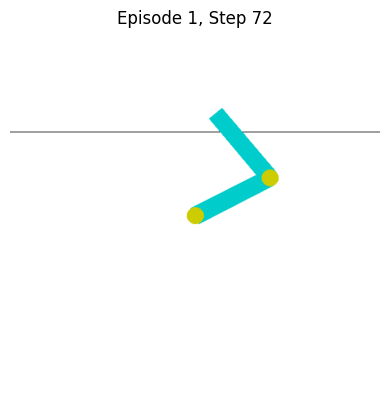

In [36]:
# YOUR CODE HERE

# You can show the policy learned by the agent using the show_policy function

show_policy(nfq_pi, n_episodes=1)